# Readout Charge-Gate Power with Reference — Estimator Development
Prototype a new estimator step by step.  
Load a pre-parsed `xarray.Dataset` from an `.h5` file and explore the raw data.

In [1]:

import os
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
import numpy as np

## 1. Configuration

In [ ]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5



H5_PATH = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\two_step_AR\ro_charge_power_post_selected.h5"
# H5_PATH = r"d:\github\LCHQMDriver\data\QPU_project\2026-04-08\#3952_LCH_charge_gate_readout_power_with_ref_0_005718\ds_raw.h5"


# Optional: paths for saving outputs (set to None to skip saving)
METADATA_SAVE_PATH = None   # e.g. r"output/state_disc_results.pkl"
FIGURE_SAVE_PATH   = os.path.join(os.path.dirname(H5_PATH), "figures")   # e.g. r"output/state_disc"
# Create figures directory under the same folder as H5_PATH
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)


# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "user_mean": [[0.1, 0.2], [0.3, 0.4]],  # initial guess for GMM centers
    # "user_std": 0.05,                         # initial guess for Gaussian std
    # "outlier_sigma": 3,                       # outlier detection threshold
}

## 2. Load Dataset

In [15]:
sq_data = load_xarray_h5(H5_PATH)
sq_data

<xarray.Dataset> Size: 60MB
Dimensions:         (prepared_state: 2, charge_gate: 49, amp_prefactor: 20,
                     shot_idx: 620)
Coordinates:
  * prepared_state  (prepared_state) int32 8B 0 1
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * shot_idx        (shot_idx) int64 5kB 0 1 2 3 4 5 ... 614 615 616 617 618 619
    qubit           object 8B 'q1'
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    outlier_mask    (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 1MB ...
Attributes:
    abscos_frequency_fixed:  0.59
    mean:                    [-0.0015745  -0.00161383]
    std:                     0.000553464982804952

## 3. Explore Dataset Structure
Inspect dimensions, coordinates, variables, and attributes.

In [16]:

print("=== Dimensions ===")
print(sq_data.dims)
print("\n=== Coordinates ===")
for name, coord in sq_data.coords.items():
    print(f"  {name}: shape={coord.shape}, dtype={coord.dtype}, values={coord.values if coord.size < 20 else f'[{coord.values[0]} ... {coord.values[-1]}] (len={coord.size})'}")
print("\n=== Data Variables ===")
for name, var in sq_data.data_vars.items():
    print(f"  {name}: shape={var.shape}, dims={var.dims}, dtype={var.dtype}")
print("\n=== Attributes ===")
for k, v in sq_data.attrs.items():
    print(f"  {k}: {v}")

=== Dimensions ===
FrozenMappingWarningOnValuesAccess({'prepared_state': 2, 'charge_gate': 49, 'amp_prefactor': 20, 'shot_idx': 620})

=== Coordinates ===
  charge_gate: shape=(49,), dtype=float64, values=[0.0 ... 0.48] (len=49)
  amp_prefactor: shape=(20,), dtype=float64, values=[0.0 ... 1.9] (len=20)
  prepared_state: shape=(2,), dtype=int32, values=[0 1]
  qubit: shape=(), dtype=object, values=q1
  shot_idx: shape=(620,), dtype=int64, values=[0 ... 619] (len=620)

=== Data Variables ===
  I1_1: shape=(2, 49, 20, 620), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_2: shape=(2, 49, 20, 620), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_3: shape=(2, 49, 20, 620), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_1: shape=(2, 49, 20, 620), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_2: shape=(2, 49, 20, 620), dims=('prepar

In [17]:

# Keep only I1_1 and Q1_1, then stack all dims into shot_idx
all_dims = list(sq_data[['I1_1', 'Q1_1']].sizes)
ds_stacked = sq_data[['I1_1', 'Q1_1']].stack(stacked=all_dims).reset_index('stacked')
n = ds_stacked.sizes['stacked']
ds_ref = xr.Dataset(
    {
        'I1_1': ('shot_idx', ds_stacked['I1_1'].values),
        'Q1_1': ('shot_idx', ds_stacked['Q1_1'].values),
    },
    coords={'shot_idx': np.arange(n)},
)
ds_ref


<xarray.Dataset> Size: 29MB
Dimensions:   (shot_idx: 1215200)
Coordinates:
  * shot_idx  (shot_idx) int64 10MB 0 1 2 3 ... 1215196 1215197 1215198 1215199
Data variables:
    I1_1      (shot_idx) float64 10MB -0.001868 -0.001334 ... 0.00298 -0.00161
    Q1_1      (shot_idx) float64 10MB -0.001556 -0.002107 ... -0.002109

In [18]:

from scqat.estimators.single_state_outlier import SingleStateOutlierEstimator

estimator = SingleStateOutlierEstimator()
results, figs = estimator.analyze(ds_ref.rename({'I1_1': 'I', 'Q1_1': 'Q'}))
results


{'fitted_paras': {'mean': array([[-0.0015745 , -0.00161383]]),
  'sigma_x': 0.000553464982804952,
  'sigma_y': 0.000553464982804952,
  'std': 0.000553464982804952,
  'amp': 488368.4782156618,
  'offset': 0.0},
 'outlier_mask': array([False, False, False, ..., False,  True, False], shape=(1215200,)),
 'outlier_indices': array([     49,     206,     218, ..., 1215194, 1215195, 1215198],
       shape=(84312,)),
 'outlier_probability': np.float64(0.06938117182356814),
 'norm_res': np.float64(0.06004488701058375),
 'fit_residue': array([[-5.62688058e-28, -3.48156886e-27, -1.78541430e-26, ...,
         -5.34833680e-53, -3.18144924e-55, -1.56851248e-57],
        [-7.45807597e-26, -4.61460035e-25, -2.36645426e-24, ...,
         -7.08888374e-51, -4.21681069e-53, -2.07896455e-55],
        [-8.19299400e-24, -5.06932258e-23, -2.59964442e-22, ...,
         -7.78742160e-49, -4.63233478e-51, -2.28382550e-53],
        ...,
        [-6.06644854e-03, -3.75354658e-02, -1.92488962e-01, ...,
         -5.76

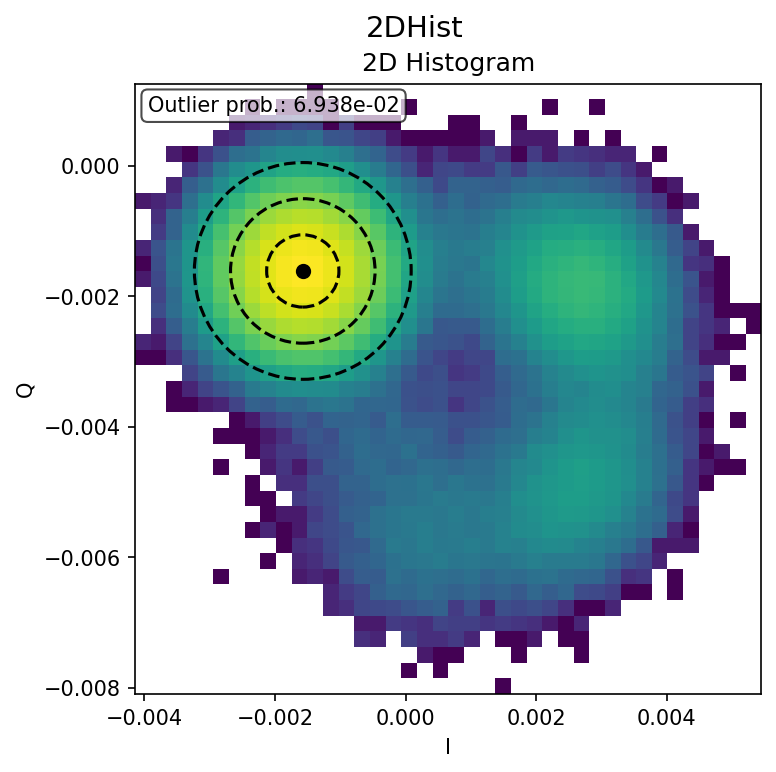

Figures saved to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\three_step_AR\figures


In [19]:

for name, fig in figs.items():
    fig.suptitle(name, fontsize=14, y=1.02)
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"post_select_{name}.png"), bbox_inches='tight')
    display(fig)
    plt.close(fig)

print(f"Figures saved to {FIGURE_SAVE_PATH}")


In [20]:

# Reshape the 1D outlier_mask back to the original multi-dim shape of I1_1
mask_shape = tuple(sq_data['I1_1'].sizes.values())
outlier_mask_nd = results["outlier_mask"].reshape(mask_shape)

# Wrap as a DataArray so xarray can broadcast / align by coordinate
mask_da = xr.DataArray(
    outlier_mask_nd,
    dims=sq_data['I1_1'].dims,
    coords={d: sq_data.coords[d] for d in sq_data['I1_1'].dims},
)

# Attach mask to sq_data; use .where(~sq_data['post_selection_mask']) downstream as needed
sq_data['post_selection_mask'] = mask_da

print(f"Outlier fraction: {results['outlier_probability']:.4f}")
sq_data


Outlier fraction: 0.0694


<xarray.Dataset> Size: 61MB
Dimensions:              (prepared_state: 2, charge_gate: 49,
                          amp_prefactor: 20, shot_idx: 620)
Coordinates:
  * prepared_state       (prepared_state) int32 8B 0 1
  * charge_gate          (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.47 0.48
  * amp_prefactor        (amp_prefactor) float64 160B 0.0 0.1 0.2 ... 1.8 1.9
  * shot_idx             (shot_idx) int64 5kB 0 1 2 3 4 ... 615 616 617 618 619
    qubit                object 8B 'q1'
Data variables:
    I1_1                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    I1_2                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    I1_3                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_1                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_2                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_3                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    outlier_mask         (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 1MB ...
    post_selection_mask  (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 1MB ...
Attributes:
    abscos_frequency_fixed:  0.59
    mean:                    [-0.0015745  -0.00161383]
    std:                     0.000553464982804952

## 5. Check: Plot Raw Data (outliers excluded)
Visualize I/Q channels across sweep coordinates after outlier masking.

Prepared states: [0 1]


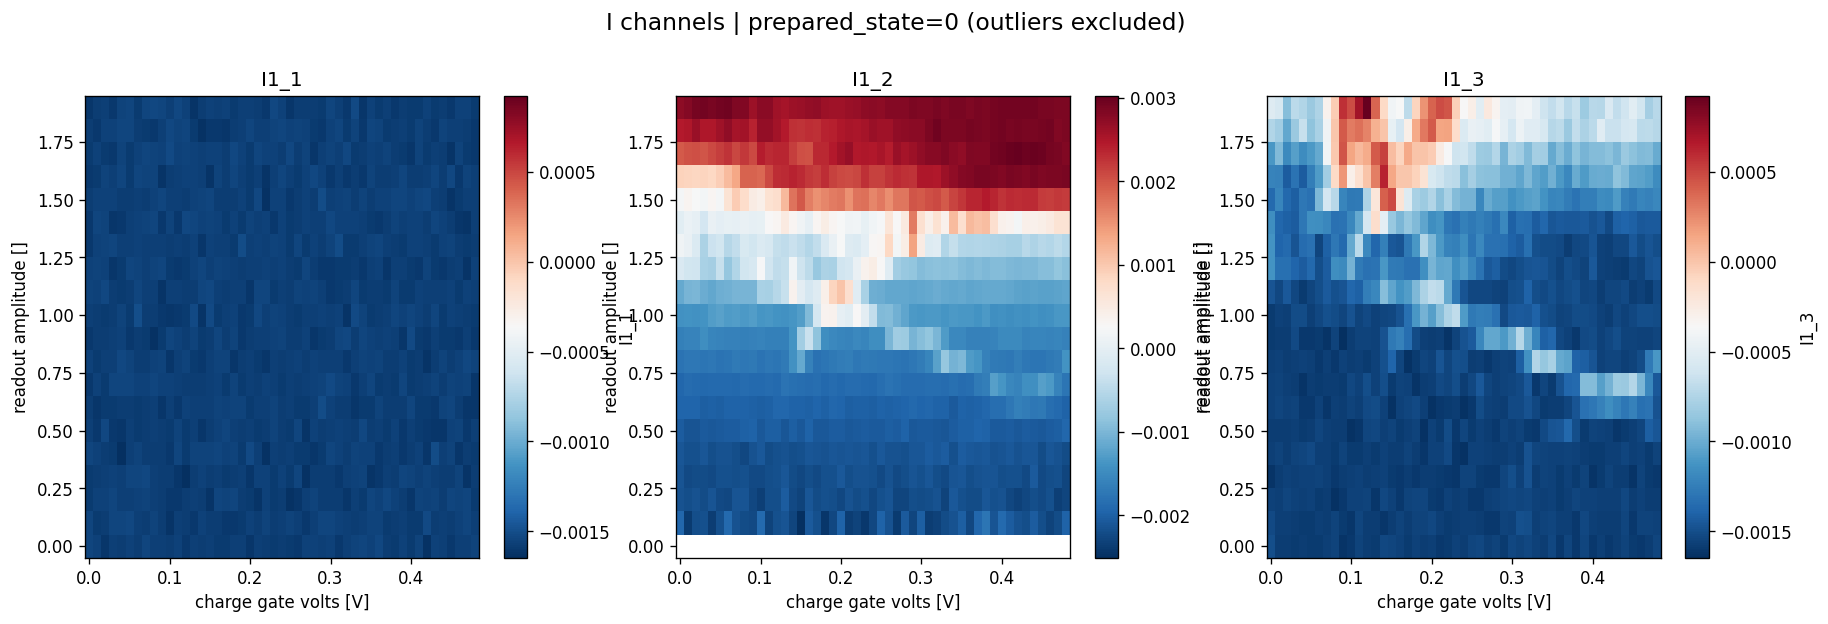

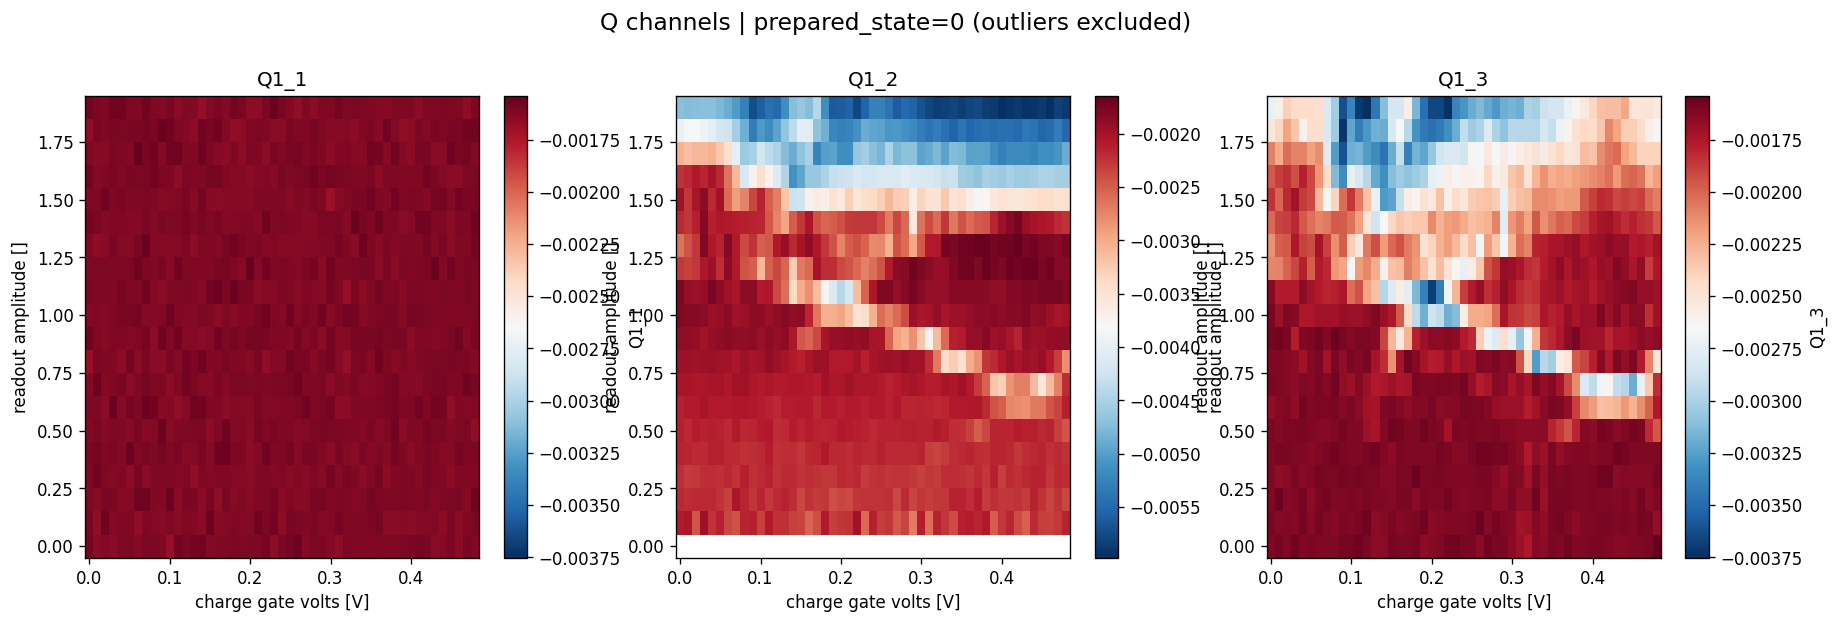

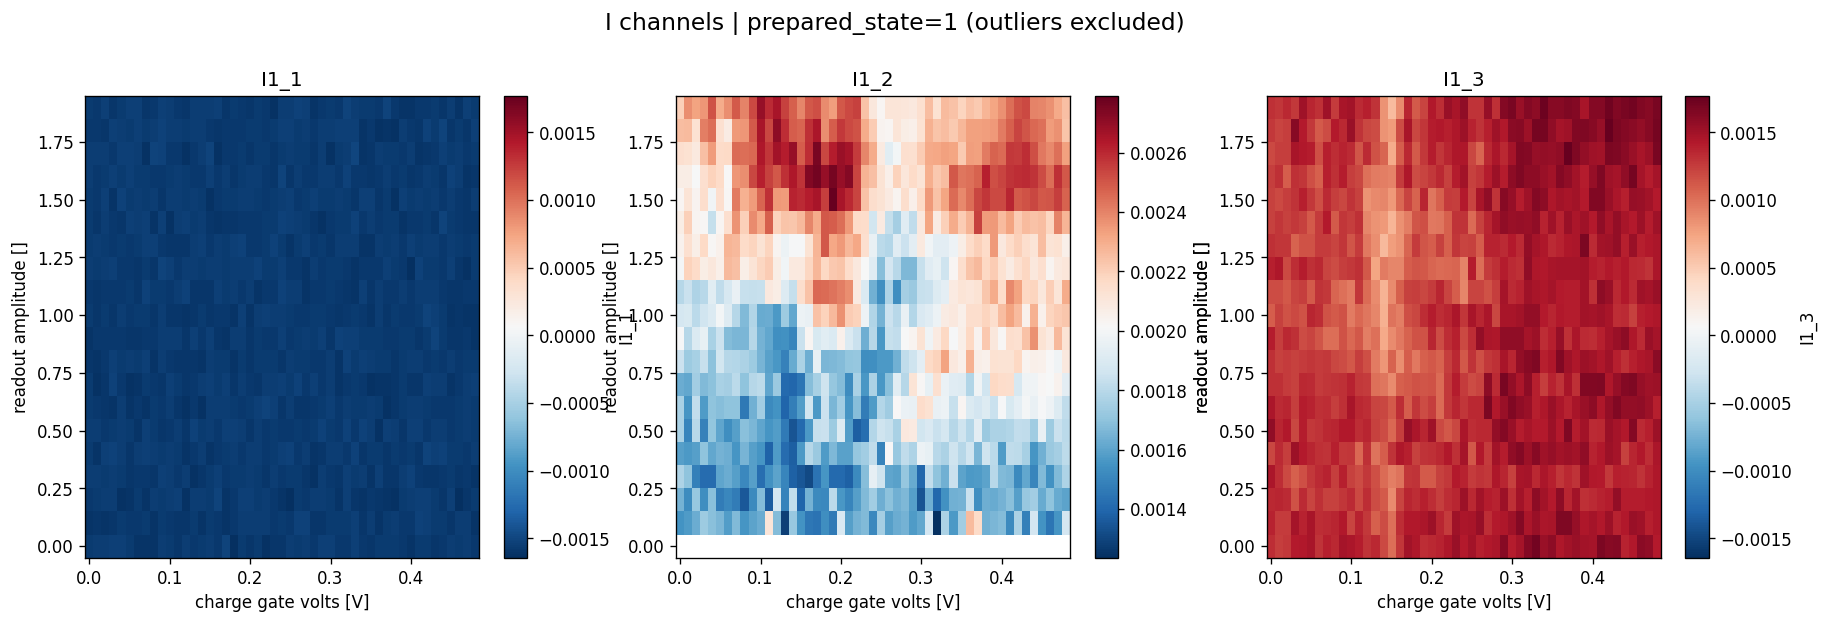

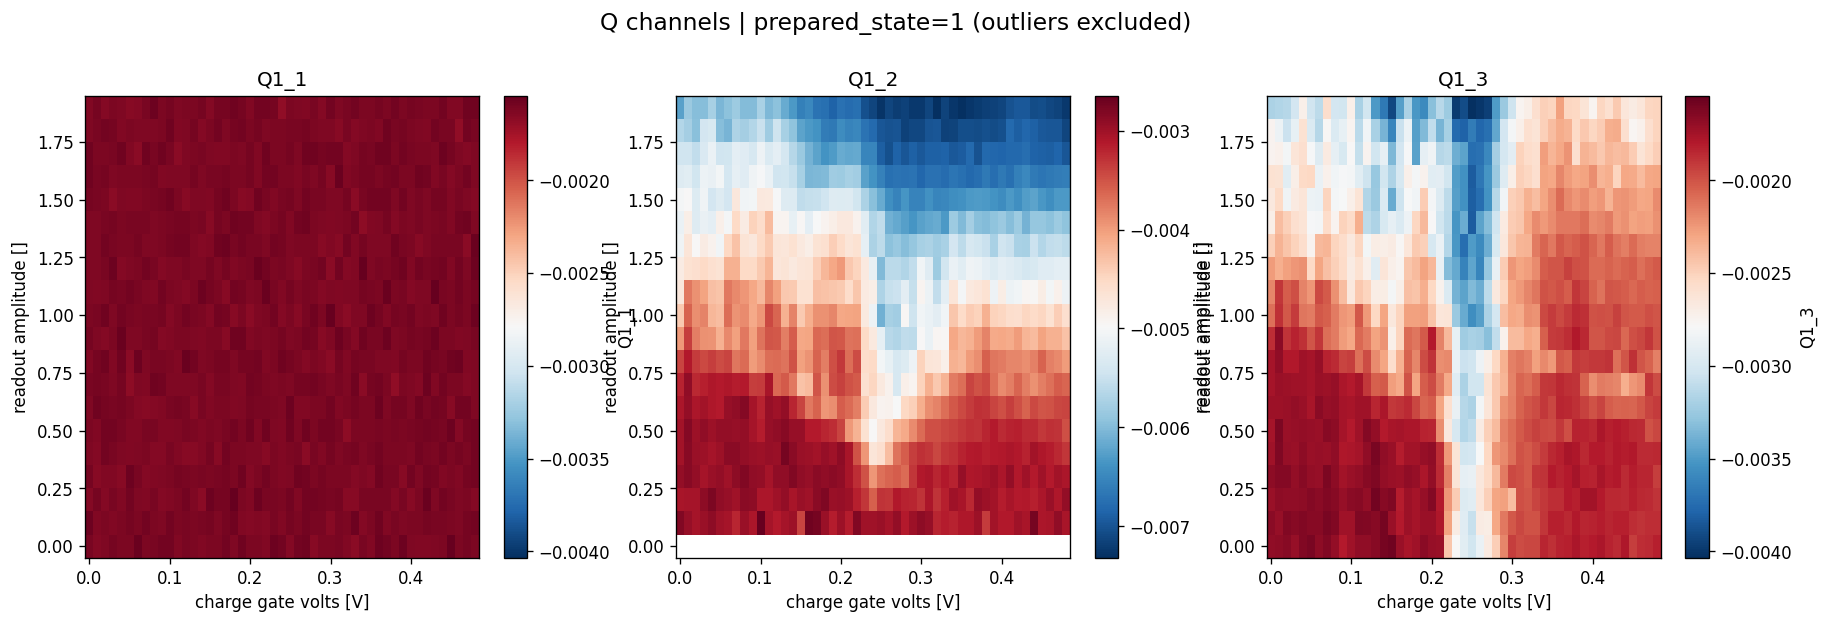

In [21]:
import numpy as np

# Group: I channels and Q channels, subplots for _1, _2, _3
# _1 and _3 share the same colorbar range; _2 has its own
i_vars = ['I1_1', 'I1_2', 'I1_3']
q_vars = ['Q1_1', 'Q1_2', 'Q1_3']
prepared_states = sq_data.coords['prepared_state'].values
print("Prepared states:", prepared_states)
for state in prepared_states:
    for group_label, group_vars in [('I', i_vars), ('Q', q_vars)]:
        # Compute means excluding outliers (where post_selection_mask is True)
        means = [sq_data[v].where(~sq_data['post_selection_mask']).mean(dim='shot_idx').sel(prepared_state=state) for v in group_vars]

        # Normalize _2 variable by amp_prefactor (skip amp_prefactor == 0)
        amp_vals = means[1].coords['amp_prefactor']
        means[1] = means[1].where(amp_vals != 0) / amp_vals.where(amp_vals != 0)

        # Shared vmin/vmax for _1 and _3 (index 0 and 2)
        shared_vmin = min(float(means[0].min()), float(means[2].min()))
        shared_vmax = max(float(means[0].max()), float(means[2].max()))

        n = len(group_vars)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), dpi=120, squeeze=False)
        for j, (var_name, mean_da) in enumerate(zip(group_vars, means)):
            if j in (0, 2):  # _1 and _3 share range
                vmin, vmax = shared_vmin, shared_vmax
            else:            # _2 uses its own range
                vmin, vmax = float(mean_da.min(skipna=True)), float(mean_da.max(skipna=True))
            mean_da.plot.pcolormesh(
                ax=axes[0, j], x='charge_gate', y='amp_prefactor',
                cmap='RdBu_r', add_colorbar=True, vmin=vmin, vmax=vmax
            )
            axes[0, j].set_title(var_name)
        fig.suptitle(f"{group_label} channels | prepared_state={state} (outliers excluded)", fontsize=14, y=1.02)
        fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"{group_label}_channels_state_{state}_post_selected.png"), bbox_inches='tight')
        display(fig)
        plt.close(fig)


In [22]:
# Save mean and std from SingleStateOutlierEstimator results as attributes in sq_data
print("Saving mean and std from outlier analysis results as attributes...")

# Extract mean and std from the results dictionary (from cell 13)
if 'mean' in results['fitted_paras']:
    sq_data.attrs['mean'] = results['fitted_paras']['mean'][0]
    print(f"Added mean as attribute: {results['fitted_paras']['mean'][0]}")

if 'std' in results['fitted_paras']:
    sq_data.attrs['std'] = results['fitted_paras']['std']
    print(f"Added std as attribute: {results['fitted_paras']['std']}")

print("Dataset attributes now include:")
for k, v in sq_data.attrs.items():
    if k in ['mean', 'std']:
        print(f"  {k}: {v}")

Saving mean and std from outlier analysis results as attributes...
Added mean as attribute: [-0.0015745  -0.00161383]
Added std as attribute: 0.000553464982804952
Dataset attributes now include:
  mean: [-0.0015745  -0.00161383]
  std: 0.000553464982804952


In [23]:
import os
output_filename = os.path.join(os.path.dirname(H5_PATH), "ro_charge_power_post_selected.h5")

# Remove existing file to avoid HDF5 lock conflict on Windows
if os.path.exists(output_filename):
    os.remove(output_filename)

print(f"Exporting dataset to {output_filename}...")
sq_data.to_netcdf(output_filename, engine='h5netcdf', invalid_netcdf=True)

print(f"Successfully exported dataset to {output_filename}")
print(f"Dataset contains {len(sq_data.data_vars)} data variables:")
for var_name in sorted(sq_data.data_vars.keys()):
    print(f"  - {var_name}")

sq_data

Exporting dataset to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\three_step_AR\ro_charge_power_post_selected.h5...
Successfully exported dataset to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\three_step_AR\ro_charge_power_post_selected.h5
Dataset contains 8 data variables:
  - I1_1
  - I1_2
  - I1_3
  - Q1_1
  - Q1_2
  - Q1_3
  - outlier_mask
  - post_selection_mask


<xarray.Dataset> Size: 61MB
Dimensions:              (prepared_state: 2, charge_gate: 49,
                          amp_prefactor: 20, shot_idx: 620)
Coordinates:
  * prepared_state       (prepared_state) int32 8B 0 1
  * charge_gate          (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.47 0.48
  * amp_prefactor        (amp_prefactor) float64 160B 0.0 0.1 0.2 ... 1.8 1.9
  * shot_idx             (shot_idx) int64 5kB 0 1 2 3 4 ... 615 616 617 618 619
    qubit                object 8B 'q1'
Data variables:
    I1_1                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    I1_2                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    I1_3                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_1                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_2                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    Q1_3                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 10MB ...
    outlier_mask         (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 1MB ...
    post_selection_mask  (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 1MB ...
Attributes:
    abscos_frequency_fixed:  0.59
    mean:                    [-0.0015745  -0.00161383]
    std:                     0.000553464982804952

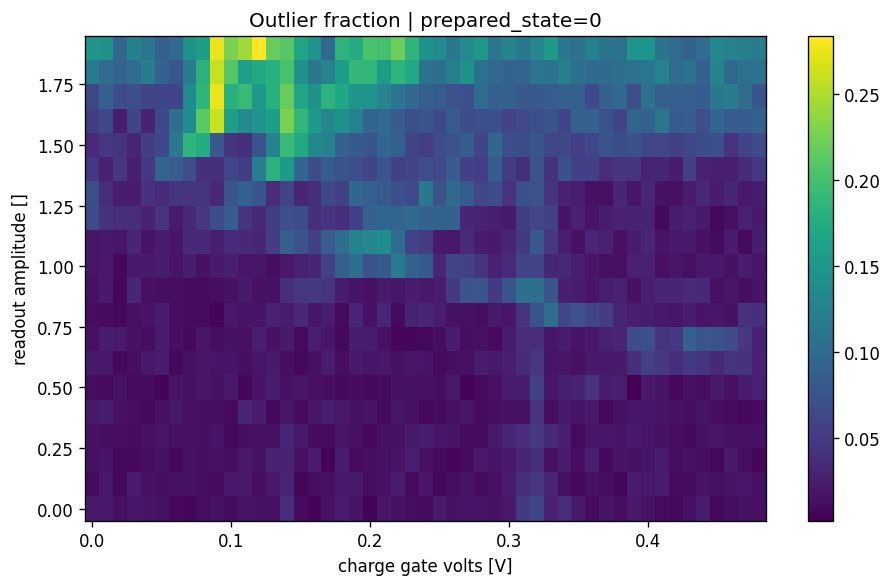

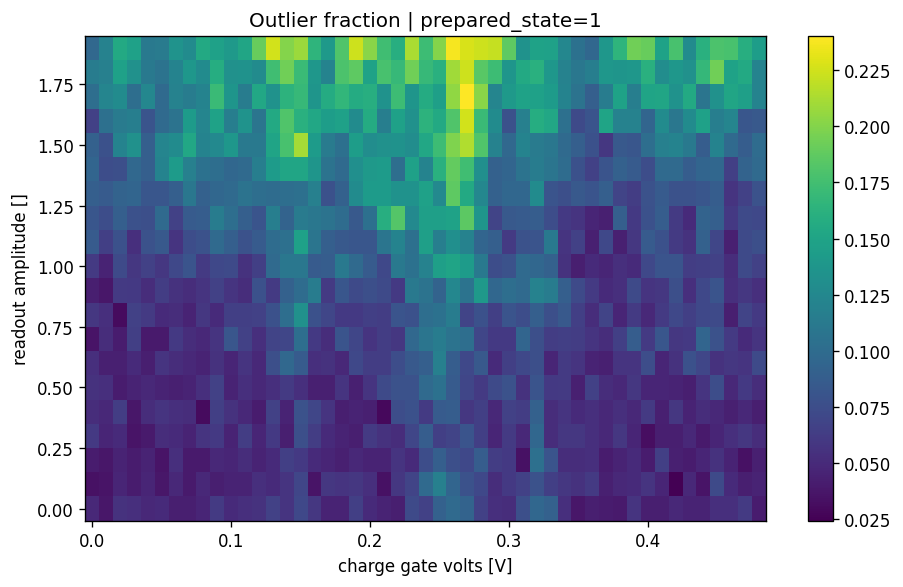

In [24]:
# Outlier fraction = mean of boolean mask along shot_idx
outlier_fraction = mask_da.mean(dim='shot_idx')

for state in outlier_fraction.coords['prepared_state'].values:
    fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
    outlier_fraction.sel(prepared_state=state).plot.pcolormesh(
        ax=ax, x='charge_gate', y='amp_prefactor',
        cmap='viridis', add_colorbar=True,
    )
    ax.set_title(f"Outlier fraction | prepared_state={int(state)}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"post_outlier_state_{int(state)}.png"), bbox_inches='tight')
    plt.show()

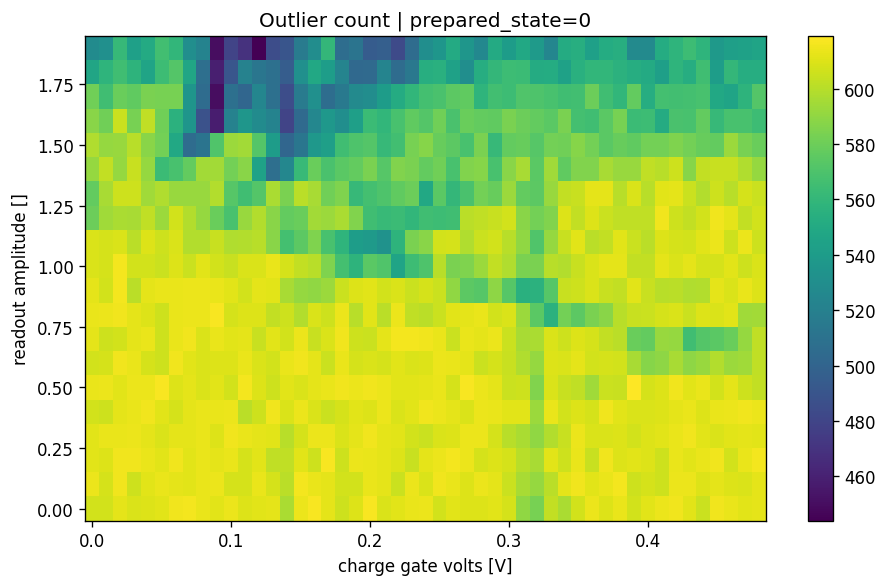

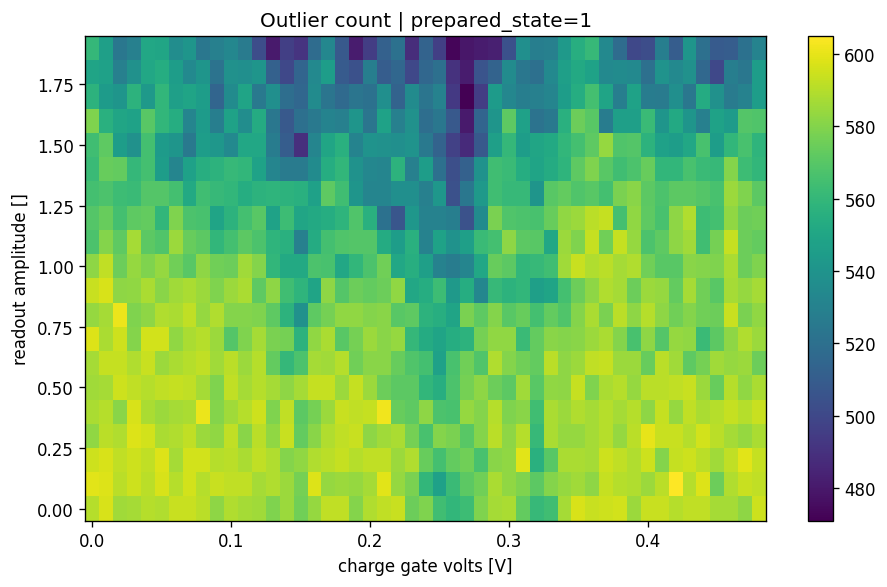

In [25]:
# Outlier count = number of False values in the boolean mask along shot_idx
outlier_count = (~mask_da).sum(dim='shot_idx')

for state in outlier_count.coords['prepared_state'].values:
    fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
    outlier_count.sel(prepared_state=state).plot.pcolormesh(
        ax=ax, x='charge_gate', y='amp_prefactor',
        cmap='viridis', add_colorbar=True,
    )
    ax.set_title(f"Outlier count | prepared_state={int(state)}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"post_outlier_count_state_{int(state)}.png"), bbox_inches='tight')
    plt.show()